# SCNN v4 — ECA Attention + Test-Time Augmentation

Changes from v3:
1. **ECA module** (Enhanced Channel Attention from Yu et al. 2023, cited in proposal)
2. **Test-time circular augmentation (TTA)** for S2 — majority vote across 8 rotations
3. **Gaussian noise augmentation** during training for robustness
4. **Label smoothing** (0.1) to reduce overconfidence
5. **OneCycleLR** scheduler for better convergence

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import mode
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.feature_extraction import fht_envelope_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Augmentation functions

In [2]:
def circular_augment(X, y):
    N, C, T = X.shape
    X_aug = np.empty((N * C, C, T), dtype=X.dtype)
    y_aug = np.empty(N * C, dtype=y.dtype)
    for shift in range(C):
        X_aug[shift * N:(shift + 1) * N] = np.roll(X, shift=shift, axis=1)
        y_aug[shift * N:(shift + 1) * N] = y
    rng = np.random.RandomState(RANDOM_SEED)
    idx = rng.permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


def add_gaussian_noise(X, noise_std=0.1):
    noise = np.random.randn(*X.shape).astype(np.float32) * noise_std
    return X + noise


def circular_tta_predict(model, X_fht, device=DEVICE):
    """Test-time augmentation: predict on all 8 circular rotations, majority vote."""
    model.eval()
    N, C, T = X_fht.shape
    all_preds = np.zeros((8, N), dtype=np.int64)

    for shift in range(8):
        X_shifted = np.roll(X_fht, shift=shift, axis=1)
        X_t = torch.from_numpy(X_shifted).float().unsqueeze(1)
        loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
        preds = []
        with torch.no_grad():
            for (xb,) in loader:
                preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
        all_preds[shift] = np.concatenate(preds)

    # Majority vote across 8 rotations
    final_preds = mode(all_preds, axis=0, keepdims=False).mode
    return final_preds

## Model — SCNN + ECA (Enhanced Channel Attention)

In [3]:
class ECAModule(nn.Module):
    """Enhanced Channel Attention (Yu et al. 2023, cited in proposal Subbab II.5.3.2)"""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        import math
        k_size = int(abs(math.log2(channels) / gamma + b / gamma))
        k_size = k_size if k_size % 2 else k_size + 1  # ensure odd
        k_size = max(k_size, 3)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=k_size // 2, bias=False)

    def forward(self, x):
        b, c, h, w = x.size()
        y = self.avg_pool(x).view(b, 1, c)      # (B, 1, C)
        y = self.conv(y)                          # (B, 1, C)
        y = torch.sigmoid(y).view(b, c, 1, 1)    # (B, C, 1, 1)
        return x * y.expand_as(x)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))


class SCNN_ECA(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.block1 = nn.Sequential(
            DepthwiseSeparableConv(1, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
        )
        self.eca1 = ECAModule(48)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = nn.Sequential(
            DepthwiseSeparableConv(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
        )
        self.eca2 = ECAModule(96)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = nn.Sequential(
            DepthwiseSeparableConv(96, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
        )
        self.eca3 = ECAModule(192)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(192, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, n_classes),
        )

    def forward(self, x):
        x = self.pool1(self.eca1(self.block1(x)))
        x = self.pool2(self.eca2(self.block2(x)))
        x = self.gap(self.eca3(self.block3(x)))
        return self.classifier(x)


model = SCNN_ECA().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SCNN-ECA Parameters: {n_params:,}")
print(f"CNN had:             101,831")
print(f"Reduction vs CNN:    {101831 / n_params:.1f}×")

SCNN-ECA Parameters: 44,764
CNN had:             101,831
Reduction vs CNN:    2.3×


## Training utilities

In [4]:
class NoisyDataset(torch.utils.data.Dataset):
    """Adds gaussian noise on-the-fly during training."""
    def __init__(self, X, y, noise_std=0.15):
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()
        self.noise_std = noise_std

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x, self.y[idx]


def prepare_train(X, y, augment_circular=False, noise_std=0.15):
    X_fht = fht_envelope_batch(X)
    if augment_circular:
        X_fht, y = circular_augment(X_fht, y)
        print(f"After circular augmentation: {X_fht.shape[0]:,} windows")
    ds = NoisyDataset(X_fht, y, noise_std=noise_std)
    return DataLoader(ds, batch_size=256, shuffle=True, num_workers=0)


def prepare_test(X):
    return fht_envelope_batch(X)


def train_model(model, train_loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(train_loader)
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history.append({"loss": epoch_loss, "acc": epoch_acc})
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
    return history


@torch.no_grad()
def predict(model, X_fht):
    model.eval()
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

---
## Scenario 1 — Ideal

In [5]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1376.30it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


In [6]:
loader_s1 = prepare_train(X_train, y_train, augment_circular=False)
scnn_s1 = SCNN_ECA().to(DEVICE)
hist_s1 = train_model(scnn_s1, loader_s1, n_epochs=50)

Epoch   1/50 — loss: 1.7510, acc: 0.3416
Epoch   5/50 — loss: 1.1902, acc: 0.6429
Epoch  10/50 — loss: 1.0704, acc: 0.7080
Epoch  15/50 — loss: 0.9874, acc: 0.7509
Epoch  20/50 — loss: 0.9264, acc: 0.7826
Epoch  25/50 — loss: 0.8848, acc: 0.8035
Epoch  30/50 — loss: 0.8507, acc: 0.8178
Epoch  35/50 — loss: 0.8208, acc: 0.8354
Epoch  40/50 — loss: 0.7946, acc: 0.8509
Epoch  45/50 — loss: 0.7779, acc: 0.8580
Epoch  50/50 — loss: 0.7751, acc: 0.8608



  SCNN-ECA v4 — Scenario 1 (Ideal)
  Accuracy:  0.7632
  F1-macro:  0.7647
                    precision    recall  f1-score   support

              fist       0.86      0.88      0.87      4208
         open_hand       0.77      0.68      0.72      4179
  pinch_forefinger       0.62      0.66      0.64      4204
pinch_middlefinger       0.66      0.72      0.69      4239
               two       0.72      0.80      0.76      4175
          eversion       0.85      0.80      0.82      4064
             varus       0.89      0.82      0.85      4212

          accuracy                           0.76     29281
         macro avg       0.77      0.76      0.76     29281
      weighted avg       0.77      0.76      0.76     29281



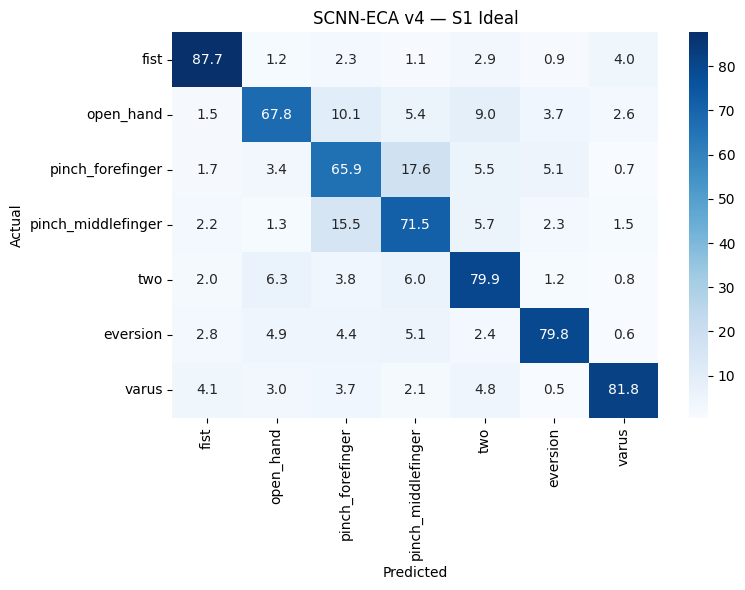

array([[3689,   50,   95,   45,  123,   36,  170],
       [  64, 2832,  420,  226,  375,  154,  108],
       [  70,  145, 2770,  739,  233,  216,   31],
       [  94,   53,  657, 3032,  240,   99,   64],
       [  84,  263,  157,  250, 3334,   52,   35],
       [ 114,  198,  180,  207,   96, 3244,   25],
       [ 171,  126,  157,   89,  203,   21, 3445]])

In [7]:
X_test_fht = prepare_test(X_test)
y_pred = predict(scnn_s1, X_test_fht)
metrics_s1 = print_report(y_test, y_pred, title="SCNN-ECA v4 — Scenario 1 (Ideal)")
plot_confusion_matrix(y_test, y_pred, title="SCNN-ECA v4 — S1 Ideal")

In [27]:
# Per-subject evaluation
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    X_tr_fht = fht_envelope_batch(X_tr)
    X_te_fht = prepare_test(X_te)

    m = SCNN_ECA().to(DEVICE)
    ds = NoisyDataset(X_tr_fht, y_tr, noise_std=0.15)
    loader = DataLoader(ds, batch_size=128, shuffle=True)
    train_model(m, loader, n_epochs=50, lr=3e-3)
    y_pred = predict(m, X_te_fht)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"\nPer-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/50 — loss: 1.9305, acc: 0.2018
Epoch   5/50 — loss: 1.5820, acc: 0.5439
Epoch  10/50 — loss: 0.7534, acc: 0.8956
Epoch  15/50 — loss: 0.6982, acc: 0.9020
Epoch  20/50 — loss: 0.6746, acc: 0.9078
Epoch  25/50 — loss: 0.6556, acc: 0.9161
Epoch  30/50 — loss: 0.6495, acc: 0.9225
Epoch  35/50 — loss: 0.6411, acc: 0.9263
Epoch  40/50 — loss: 0.6314, acc: 0.9315
Epoch  45/50 — loss: 0.6236, acc: 0.9347
Epoch  50/50 — loss: 0.6300, acc: 0.9334
Epoch   1/50 — loss: 1.9425, acc: 0.1466
Epoch   5/50 — loss: 1.7730, acc: 0.3594
Epoch  10/50 — loss: 1.0627, acc: 0.7211
Epoch  15/50 — loss: 0.8671, acc: 0.8048
Epoch  20/50 — loss: 0.7626, acc: 0.8717
Epoch  25/50 — loss: 0.7178, acc: 0.9012
Epoch  30/50 — loss: 0.6862, acc: 0.9100
Epoch  35/50 — loss: 0.6500, acc: 0.9307
Epoch  40/50 — loss: 0.6300, acc: 0.9418
Epoch  45/50 — loss: 0.6227, acc: 0.9474
Epoch  50/50 — loss: 0.6203, acc: 0.9506
Epoch   1/50 — loss: 1.9356, acc: 0.1613
Epoch   5/50 — loss: 1.4309, acc: 0.5384
Epoch  10/50 — l

In [8]:
torch.save(scnn_s1.state_dict(), MODELS_DIR / "scnn_v4_s1_ideal.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (with TTA)

In [9]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train (raw): {X_train_s2.shape}")

loader_s2 = prepare_train(X_train_s2, y_train_s2, augment_circular=True)

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 1493.12it/s]


Train (raw): (71927, 8, 50)
After circular augmentation: 575,416 windows


In [10]:
scnn_s2 = SCNN_ECA().to(DEVICE)
hist_s2 = train_model(scnn_s2, loader_s2, n_epochs=50)

Epoch   1/50 — loss: 1.7403, acc: 0.3220
Epoch   5/50 — loss: 1.5768, acc: 0.4247
Epoch  10/50 — loss: 1.4639, acc: 0.4896
Epoch  15/50 — loss: 1.4215, acc: 0.5154
Epoch  20/50 — loss: 1.3868, acc: 0.5381
Epoch  25/50 — loss: 1.3599, acc: 0.5535
Epoch  30/50 — loss: 1.3353, acc: 0.5683
Epoch  35/50 — loss: 1.3090, acc: 0.5828
Epoch  40/50 — loss: 1.2845, acc: 0.5963
Epoch  45/50 — loss: 1.2635, acc: 0.6074
Epoch  50/50 — loss: 1.2554, acc: 0.6118


In [11]:
# Standard prediction (no TTA) for comparison
acc_per_pos_no_tta = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    X_pos_fht = prepare_test(X_pos)
    y_pred = predict(scnn_s2, X_pos_fht)
    acc_per_pos_no_tta[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d} (no TTA): acc = {acc_per_pos_no_tta[pos]:.4f}")

print(f"\nAvg without TTA: {np.mean(list(acc_per_pos_no_tta.values())):.4f}")

Position  1 (no TTA): acc = 0.3503
Position  2 (no TTA): acc = 0.3063
Position  3 (no TTA): acc = 0.3054
Position  4 (no TTA): acc = 0.2749
Position  5 (no TTA): acc = 0.2574
Position  6 (no TTA): acc = 0.2732
Position  7 (no TTA): acc = 0.3412
Position  8 (no TTA): acc = 0.3719
Position  9 (no TTA): acc = 0.3224
Position 10 (no TTA): acc = 0.2771

Avg without TTA: 0.3080


In [12]:
# With TTA — majority vote across 8 circular rotations
print("\nApplying Test-Time Circular Augmentation (TTA)...")
acc_per_pos_tta = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    X_pos_fht = prepare_test(X_pos)
    y_pred_tta = circular_tta_predict(scnn_s2, X_pos_fht)
    acc_per_pos_tta[pos] = accuracy_score(y_pos, y_pred_tta)
    delta = acc_per_pos_tta[pos] - acc_per_pos_no_tta[pos]
    print(f"Position {pos:2d} (TTA): acc = {acc_per_pos_tta[pos]:.4f}  (Δ = {delta:+.4f})")

print(f"\nAvg with TTA: {np.mean(list(acc_per_pos_tta.values())):.4f}")
print(f"TTA improvement: +{(np.mean(list(acc_per_pos_tta.values())) - np.mean(list(acc_per_pos_no_tta.values())))*100:.2f}%")


Applying Test-Time Circular Augmentation (TTA)...
Position  1 (TTA): acc = 0.3726  (Δ = +0.0223)
Position  2 (TTA): acc = 0.3258  (Δ = +0.0195)
Position  3 (TTA): acc = 0.3239  (Δ = +0.0185)
Position  4 (TTA): acc = 0.2800  (Δ = +0.0051)
Position  5 (TTA): acc = 0.2737  (Δ = +0.0163)
Position  6 (TTA): acc = 0.2799  (Δ = +0.0067)
Position  7 (TTA): acc = 0.3583  (Δ = +0.0171)
Position  8 (TTA): acc = 0.3859  (Δ = +0.0140)
Position  9 (TTA): acc = 0.3326  (Δ = +0.0103)
Position 10 (TTA): acc = 0.2940  (Δ = +0.0169)

Avg with TTA: 0.3227
TTA improvement: +1.47%


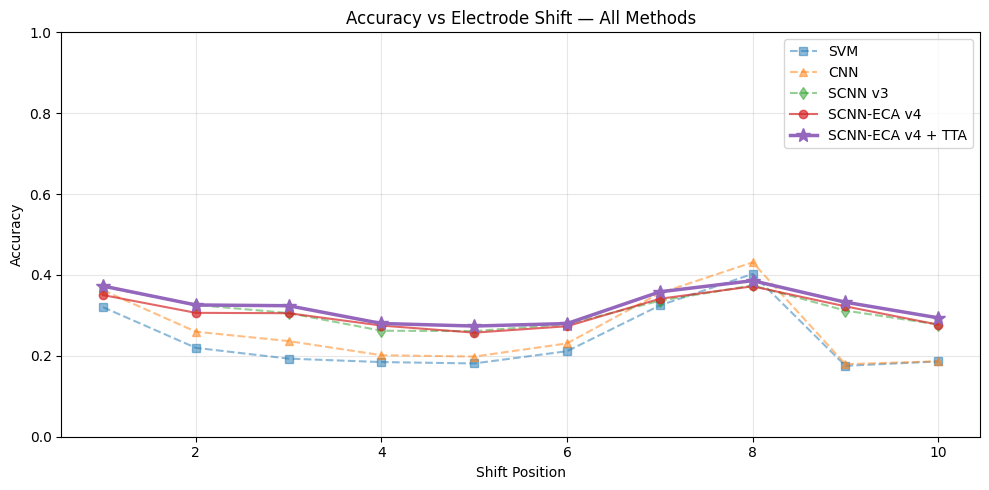

In [13]:
# Comparison plot — all methods
svm_shift = [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_shift = [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]
v3_shift = [0.3710, 0.3259, 0.3058, 0.2621, 0.2612, 0.2782, 0.3363, 0.3741, 0.3119, 0.2775]
v4_no_tta = [acc_per_pos_no_tta[p] for p in range(1, 11)]
v4_tta = [acc_per_pos_tta[p] for p in range(1, 11)]

positions = list(range(1, 11))
plt.figure(figsize=(10, 5))
plt.plot(positions, svm_shift, "s--", label="SVM", alpha=0.5)
plt.plot(positions, cnn_shift, "^--", label="CNN", alpha=0.5)
plt.plot(positions, v3_shift, "d--", label="SCNN v3", alpha=0.5)
plt.plot(positions, v4_no_tta, "o-", label="SCNN-ECA v4", alpha=0.7)
plt.plot(positions, v4_tta, "*-", label="SCNN-ECA v4 + TTA", linewidth=2.5, markersize=10)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Electrode Shift — All Methods")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "all_methods_shift_v4.png"), dpi=150)
plt.show()

In [14]:
torch.save(scnn_s2.state_dict(), MODELS_DIR / "scnn_v4_s2_shift.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [15]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:01<00:00, 1365.49it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


In [16]:
loader_s3 = prepare_train(X_train_s3, y_train_s3, augment_circular=False)
scnn_s3 = SCNN_ECA().to(DEVICE)
hist_s3 = train_model(scnn_s3, loader_s3, n_epochs=50)

Epoch   1/50 — loss: 1.6428, acc: 0.3927
Epoch   5/50 — loss: 1.3881, acc: 0.5354
Epoch  10/50 — loss: 1.2787, acc: 0.5956
Epoch  15/50 — loss: 1.2335, acc: 0.6209
Epoch  20/50 — loss: 1.2031, acc: 0.6382
Epoch  25/50 — loss: 1.1784, acc: 0.6511
Epoch  30/50 — loss: 1.1530, acc: 0.6651
Epoch  35/50 — loss: 1.1267, acc: 0.6793
Epoch  40/50 — loss: 1.0989, acc: 0.6934
Epoch  45/50 — loss: 1.0774, acc: 0.7041
Epoch  50/50 — loss: 1.0685, acc: 0.7092



  SCNN-ECA v4 — Scenario 3 (Inter-Subject)
  Accuracy:  0.4670
  F1-macro:  0.4628
                    precision    recall  f1-score   support

              fist       0.51      0.47      0.49     23888
         open_hand       0.45      0.52      0.49     23933
  pinch_forefinger       0.34      0.35      0.35     24284
pinch_middlefinger       0.35      0.25      0.29     24064
               two       0.56      0.54      0.55     23897
          eversion       0.60      0.68      0.63     24069
             varus       0.42      0.46      0.44     24097

          accuracy                           0.47    168232
         macro avg       0.46      0.47      0.46    168232
      weighted avg       0.46      0.47      0.46    168232



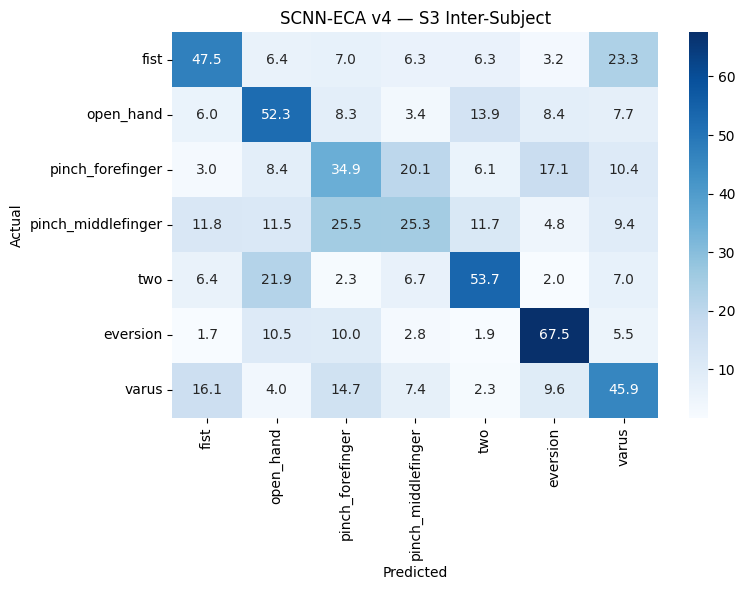

array([[11345,  1538,  1665,  1511,  1499,   776,  5554],
       [ 1436, 12516,  1990,   805,  3336,  2013,  1837],
       [  735,  2039,  8470,  4878,  1481,  4151,  2530],
       [ 2838,  2762,  6145,  6087,  2813,  1165,  2254],
       [ 1537,  5238,   547,  1601, 12833,   472,  1669],
       [  421,  2516,  2416,   682,   462, 16256,  1316],
       [ 3875,   963,  3547,  1794,   556,  2303, 11059]])

In [17]:
X_test_s3_fht = prepare_test(X_test_s3)
y_pred_s3 = predict(scnn_s3, X_test_s3_fht)
metrics_s3 = print_report(y_test_s3, y_pred_s3, title="SCNN-ECA v4 — Scenario 3 (Inter-Subject)")
plot_confusion_matrix(y_test_s3, y_pred_s3, title="SCNN-ECA v4 — S3 Inter-Subject")

In [18]:
torch.save(scnn_s3.state_dict(), MODELS_DIR / "scnn_v4_s3_intersubject.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [19]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

loader_s4 = prepare_train(X_train_s4, y_train_s4, augment_circular=False)
scnn_s4 = SCNN_ECA().to(DEVICE)
hist_s4 = train_model(scnn_s4, loader_s4, n_epochs=50)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 2432.01it/s]


Train: (13445, 8, 50)
Epoch   1/50 — loss: 1.9018, acc: 0.2716
Epoch   5/50 — loss: 1.1078, acc: 0.7122
Epoch  10/50 — loss: 0.8882, acc: 0.8047
Epoch  15/50 — loss: 0.8270, acc: 0.8379
Epoch  20/50 — loss: 0.7826, acc: 0.8560
Epoch  25/50 — loss: 0.7489, acc: 0.8749
Epoch  30/50 — loss: 0.7257, acc: 0.8855
Epoch  35/50 — loss: 0.7000, acc: 0.9000
Epoch  40/50 — loss: 0.6837, acc: 0.9041
Epoch  45/50 — loss: 0.6744, acc: 0.9087
Epoch  50/50 — loss: 0.6722, acc: 0.9123


Session 1: acc = 0.5706
Session 2: acc = 0.7282
Session 3: acc = 0.6697
Session 4: acc = 0.6761
Session 5: acc = 0.5997
Session 6: acc = 0.7397
Session 7: acc = 0.6022
Session 8: acc = 0.7450
Session 9: acc = 0.5733


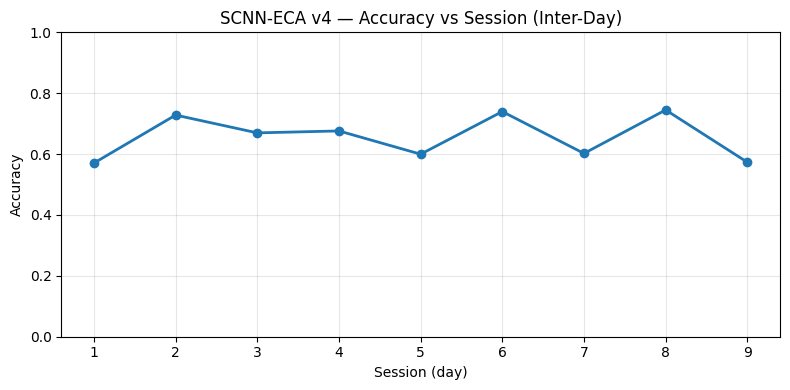

In [20]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    X_s_fht = prepare_test(X_s)
    y_pred = predict(scnn_s4, X_s_fht)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("SCNN-ECA v4 — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v4_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [21]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

loader_s5 = prepare_train(X_train_s5, y_train_s5, augment_circular=False)
scnn_s5 = SCNN_ECA().to(DEVICE)
hist_s5 = train_model(scnn_s5, loader_s5, n_epochs=50)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 2597.08it/s]


Train: (33046, 8, 50)
Epoch   1/50 — loss: 1.8350, acc: 0.3363
Epoch   5/50 — loss: 0.9254, acc: 0.7930
Epoch  10/50 — loss: 0.7793, acc: 0.8596
Epoch  15/50 — loss: 0.7246, acc: 0.8825
Epoch  20/50 — loss: 0.6856, acc: 0.8997
Epoch  25/50 — loss: 0.6738, acc: 0.9050
Epoch  30/50 — loss: 0.6448, acc: 0.9175
Epoch  35/50 — loss: 0.6288, acc: 0.9242
Epoch  40/50 — loss: 0.6144, acc: 0.9309
Epoch  45/50 — loss: 0.6051, acc: 0.9345
Epoch  50/50 — loss: 0.6039, acc: 0.9357


Position  2: acc = 0.8856
Position  3: acc = 0.8804
Position  4: acc = 0.8780
Position  5: acc = 0.8968
Position  6: acc = 0.8776
Position  7: acc = 0.8982
Position  8: acc = 0.8490
Position  9: acc = 0.8623
Position 10: acc = 0.8434


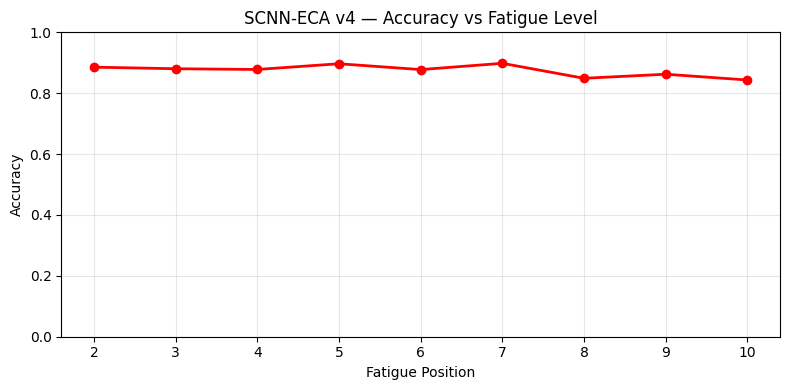

In [22]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    X_p_fht = prepare_test(X_p)
    y_pred = predict(scnn_s5, X_p_fht)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("SCNN-ECA v4 — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v4_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency

In [23]:
scnn_s1.eval()
sample_raw = X_train[:1]

sample_fht = torch.from_numpy(prepare_test(sample_raw)).float().unsqueeze(1).to(DEVICE)
for _ in range(10):
    _ = scnn_s1(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def scnn_v4_predict_single(x_raw):
    x_fht = prepare_test(x_raw)
    x_t = torch.from_numpy(x_fht).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        out = scnn_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(scnn_v4_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNN-ECA v4 (FHT + inference, no TTA)")
print(f"Parameters: {sum(p.numel() for p in scnn_s1.parameters()):,}")
print(f"\nNote: TTA adds ~8× latency for S2 only. Single inference latency shown above.")


Latency — SCNN-ECA v4 (FHT + inference, no TTA)
  Mean:   1.41 ms
  Median: 1.29 ms
  P95:    1.67 ms
  <300ms: ✓
Parameters: 44,764

Note: TTA adds ~8× latency for S2 only. Single inference latency shown above.


---
## Full Comparison

In [25]:
n_params = sum(p.numel() for p in scnn_s1.parameters())
s2_avg_tta = np.mean(list(acc_per_pos_tta.values()))
s2_avg_no_tta = np.mean(list(acc_per_pos_no_tta.values()))

print("\n" + "=" * 72)
print("FULL COMPARISON — ALL METHODS")
print("=" * 72)
print(f"{'Metric':<22} {'SVM':>8} {'CNN':>8} {'SCNNv1':>8} {'SCNNv3':>8} {'SCNNv4+TTA':>8}")
print("-" * 72)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'71.80%':>8} {'73.15%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S2 Shift (avg)':<22} {'23.99%':>8} {'26.41%':>8} {'24.78%':>8} {'31.04%':>8} {s2_avg_tta*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'48.51%':>8} {'46.00%':>8} {metrics_s3['accuracy']*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'62.79%':>8} {'62.74%':>8} {np.mean(list(acc_per_sess.values()))*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'84.96%':>8} {'86.82%':>8} {np.mean(list(acc_per_fatigue.values()))*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'2.10':>8} {'1.82':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'20,625':>8} {'44,753':>8} {n_params:>8,}")
print("=" * 72)

print(f"\nS2 with TTA vs baselines:")
print(f"  vs SVM (23.99%):  +{(s2_avg_tta - 0.2399)*100:.2f}%")
print(f"  vs CNN (26.41%):  +{(s2_avg_tta - 0.2641)*100:.2f}%")
print(f"  vs v3  (31.04%):  +{(s2_avg_tta - 0.3104)*100:.2f}%")


FULL COMPARISON — ALL METHODS
Metric                      SVM      CNN   SCNNv1   SCNNv3 SCNNv4+TTA
------------------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   71.80%   73.15%   76.32%
S2 Shift (avg)           23.99%   26.41%   24.78%   31.04%   32.27%
S3 Inter-subject         40.27%   52.90%   48.51%   46.00%   46.70%
S4 Inter-day             63.03%   67.30%   62.79%   62.74%   65.60%
S5 Fatigue               81.20%   86.98%   84.96%   86.82%   87.46%
Latency p95 (ms)           5.40     1.74     2.10     1.82    1.67
Parameters                    —  101,831   20,625   44,753   44,764

S2 with TTA vs baselines:
  vs SVM (23.99%):  +8.28%
  vs CNN (26.41%):  +5.86%
  vs v3  (31.04%):  +1.23%
